<a href="https://colab.research.google.com/github/yassine1208/TP_4/blob/main/TP5_Transfer_Learning_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 — Transfer Learning par extraction de features dans un CNN (VGG16)
## Solutions complètes

> **Environnement recommandé :** Google Colab avec GPU.  
> *Exécution → Modifier le type d'exécution → GPU*  
> Exécuter toutes les cellules dans l'ordre.


## 0 – Installation et imports

In [1]:
import os, time, pickle, requests, zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Partie 1 – Architecture VGG16

### Questions théoriques

---

**Q1 ★ — Estimation du nombre de paramètres de VGG16**

D'après la Figure 1, les dimensions clés sont :

| Section | Tenseur sortant | Paramètres (approximation) |
|---|---|---|
| Bloc conv 1 | 224×224×64 | (3×3×3+1)×64 + (3×3×64+1)×64 ≈ **38 k** |
| Bloc conv 2 | 112×112×128 | (3×3×64+1)×128×2 ≈ **148 k** |
| Bloc conv 3 | 56×56×256 | (3×3×128+1)×256×3 ≈ **885 k** |
| Bloc conv 4 | 28×28×512 | (3×3×256+1)×512×3 ≈ **3 540 k** |
| Bloc conv 5 | 14×14×512 | (3×3×512+1)×512×3 ≈ **7 079 k** |
| **FC1** (7×7×512 → 4096) | 4096 | 7×7×512×4096 + 4096 ≈ **102 764 k** |
| **FC2** (4096 → 4096) | 4096 | 4096×4096 + 4096 ≈ **16 781 k** |
| **FC3** (4096 → 1000) | 1000 | 4096×1000 + 1000 ≈ **4 097 k** |

**Total ≈ 138 millions de paramètres**, dont ~88 % dans les couches FC.  
(Valeur exacte PyTorch : 138 357 544)

---

**Q2 — Taille de sortie de la dernière couche de VGG16**

La dernière couche produit un vecteur de taille **1 000**.  
Chaque composante correspond au **score (logit) d'une classe** parmi les 1 000 classes d'ImageNet.  
Après softmax, ces scores deviennent des probabilités d'appartenance à chaque classe.

---

**Q5 ★ — Pourquoi ne pas apprendre VGG16 directement sur 15 Scene ?**

1. **Données insuffisantes :** 15 Scene contient ~4 500 images (~300/classe).  
   Entraîner 138 M de paramètres à partir de zéro sur si peu d'exemples → sur-apprentissage massif.  
2. **Coût computationnel :** Des centaines d'heures GPU pour converger.  
3. **Redondance :** Les filtres conv appris sur ImageNet (bords, textures, formes)  
   sont déjà pertinents pour reconnaître des scènes.

---

**Q6 ★ — En quoi le pré-apprentissage sur ImageNet aide pour 15 Scene ?**

ImageNet contient 1,2 M images couvrant une très grande variété visuelle.  
Le réseau a appris des représentations hiérarchiques **généralisables** :  
- Couches basses : bords, coins, textures  
- Couches moyennes : parties d'objets  
- Couches hautes : sémantique (fourrure, béton, végétation…)  

Ces représentations sont *transférables* à 15 Scene car les scènes sont composées  
des mêmes objets et textures que celles d'ImageNet. On parle de **transfert de domaine**.

---

**Q7 — Limites de l'approche par feature extraction**

- Si le domaine cible est très différent d'ImageNet (images médicales, satellite, infrarouge…),  
  les features extraites peuvent être peu informatives.  
- La représentation est **figée** : on ne l'adapte pas aux spécificités de 15 Scene.  
- Les images N&B de 15 Scene nécessitent une adaptation (duplication des canaux, cf. Q9).  
- Le vecteur de 4096 dimensions reste de grande taille → risque de malédiction de la dimension pour le SVM.

---

**Q8 — Influence de la couche d'extraction**

| Couche | Taille | Caractère |
|---|---|---|
| conv1 (début) | 224×224×64 | Primitives locales (bords) |
| pool3 (milieu conv) | 28×28×256 | Textures, motifs locaux |
| relu6 / relu7 (FC) | 4096 | Sémantique haut niveau |
| fc8 (dernière) | 1000 | Spécifique aux 1000 classes ImageNet |

Plus on extrait **profond**, plus les features sont sémantiques et compactes,  
mais aussi plus elles dépendent de la tâche ImageNet.  
`relu7` est empiriquement le meilleur compromis généralisation / sémantique.

---

**Q9 — Images N&B → RGB pour VGG16**

15 Scene est en niveaux de gris (1 canal). VGG16 attend 3 canaux.  
Solution : **dupliquer le canal de gris 3 fois** → image RGB artificielle où R=G=B=gris.  
```python
if img.mode != 'RGB':
    img = img.convert('RGB')
```
`PIL.Image.convert('RGB')` gère automatiquement les cas N&B et RGBA.

---

**Q10 — Utiliser uniquement le réseau sans SVM séparé**

Oui, deux approches :  
1. **Feature extraction + tête linéaire :** Remplacer la dernière couche FC (1000 sorties)  
   par une nouvelle couche FC (15 sorties) et entraîner *uniquement* cette couche.  
2. **Fine-tuning complet :** Entraîner toutes les couches (ou les derniers blocs) avec un  
   learning rate très faible pour adapter le réseau entier à 15 Scene.  
   → Meilleures performances mais nécessite plus de données et de calcul.


In [2]:
# ----- Chargement de VGG16 pré-entraîné -----
vgg16 = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
vgg16 = vgg16.to(device)
vgg16.eval()

total_params = sum(p.numel() for p in vgg16.parameters())
print(f"Nombre total de paramètres VGG16 : {total_params:,}")
print()
print(vgg16)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 143MB/s]


Nombre total de paramètres VGG16 : 138,357,544

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2

In [3]:
# ----- Prédiction sur une image de test (Q3 bonus) -----
# Transformations ImageNet standard
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# On utilise une image de test depuis torchvision (pas besoin de fichier externe)
from torchvision.datasets import CIFAR10
_ds = CIFAR10(root='datasets', train=False, download=True,
              transform=transforms.ToTensor())

# Créer une petite galerie de prédictions VGG16 sur 3 images CIFAR
# (VGG16 ne reconnaîtra pas les classes CIFAR précisément, c'est illustratif)
# Utiliser des images PIL réelles si disponibles

# Charger les 1000 noms de classes ImageNet depuis torchvision
IMAGENET_LABELS = {idx: label for idx, label in
                   enumerate(torchvision.models.VGG16_Weights.IMAGENET1K_V1.meta["categories"])}

def predict_image(pil_img, model, top_k=5):
    """Prédit les top_k classes ImageNet pour une image PIL."""
    tensor = imagenet_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]
    top_probs, top_idxs = probs.topk(top_k)
    return [(IMAGENET_LABELS[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]

# Test rapide avec une image CIFAR convertie en PIL
sample_tensor, sample_label = _ds[0]
sample_pil = transforms.ToPILImage()(sample_tensor)
preds = predict_image(sample_pil, vgg16)
print("Top-5 prédictions VGG16 (image test CIFAR) :")
for label, prob in preds:
    print(f"  {label:<30s} {prob*100:.1f}%")


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Top-5 prédictions VGG16 (image test CIFAR) :
  platypus                       22.4%
  triceratops                    4.9%
  polecat                        3.8%
  nipple                         3.5%
  fox squirrel                   3.1%


## Partie 2 – Transfer Learning sur 15 Scene

### 2.1 Téléchargement de la base 15 Scene


In [4]:
# ---- Téléchargement de la base 15 Scenes ----
# Téléchargement depuis un miroir GitHub fonctionnel
DATASET_URL = "https://github.com/swarathesh/15-scene-dataset/archive/refs/heads/master.zip"
DATASET_DIR = Path("15scene")

# Vérifier d'abord si les classes existent déjà
scene_root = None
for candidate in [DATASET_DIR / "15-Scene",
                  DATASET_DIR / "scene_categories",
                  DATASET_DIR / "15-scene-dataset-master" / "15-Scene",
                  DATASET_DIR,
                  Path("scene_categories")]:
    if candidate.exists() and candidate.is_dir():
        if any(p.is_dir() for p in candidate.iterdir()):
            scene_root = candidate
            break

if not scene_root:
    print("Classes non trouvées. Téléchargement de 15 Scene (~200 MB)...")
    os.makedirs(DATASET_DIR, exist_ok=True)
    try:
        r = requests.get(DATASET_URL, stream=True, timeout=60)
        zip_path = Path("15scene.zip")
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Extraction en cours...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATASET_DIR)
        zip_path.unlink()
        print("Téléchargement et extraction terminés.")
    except Exception as e:
        print(f"Erreur lors du téléchargement: {e}")
        print("Veuillez télécharger le dataset manuellement.")

    # Re-chercher scene_root après téléchargement
    for candidate in [DATASET_DIR / "15-Scene",
                      DATASET_DIR / "scene_categories",
                      DATASET_DIR / "15-scene-dataset-master" / "15-Scene",
                      DATASET_DIR,
                      Path("scene_categories")]:
        if candidate.exists() and candidate.is_dir():
            if any(p.is_dir() for p in candidate.iterdir()):
                scene_root = candidate
                break
else:
    print("Dataset déjà présent et classes trouvées.")

if scene_root:
    classes = sorted([p.name for p in scene_root.iterdir() if p.is_dir()])
    print(f"Classes trouvées ({len(classes)}) :", classes)
else:
    raise FileNotFoundError("Impossible de trouver le dossier des classes du dataset. Vérifiez l'extraction.")


Classes non trouvées. Téléchargement de 15 Scene (~200 MB)...
Extraction en cours...
Téléchargement et extraction terminés.
Classes trouvées (15) : ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14']


In [5]:
# ---- Création des splits train/test depuis les dossiers de classes ----
import random

def build_splits(scene_root, classes, train_ratio=0.7, seed=42):
    """Construit des listes (path, label) pour train et test."""
    random.seed(seed)
    train_items, test_items = [], []
    for cls in classes:
        cls_dir = scene_root / cls
        if not cls_dir.exists(): continue
        imgs = sorted(list(cls_dir.glob("*.jpg")) +
                      list(cls_dir.glob("*.png")) +
                      list(cls_dir.glob("*.pgm")))
        random.shuffle(imgs)
        split = int(len(imgs) * train_ratio)
        train_items += [(p, cls) for p in imgs[:split]]
        test_items  += [(p, cls) for p in imgs[split:]]
    return train_items, test_items

train_items, test_items = build_splits(scene_root, classes)

print(f"Train: {len(train_items)} images  |  Test: {len(test_items)} images")
print(f"Classes ({len(classes)}): {classes[:5]} ...")


Train: 3131 images  |  Test: 1351 images
Classes (15): ['00', '01', '02', '03', '04'] ...


### 2.2 Extraction des features VGG16 à la couche relu7

In [6]:
# ---- Modèle tronqué à relu7 ----
class VGG16relu7(nn.Module):
    """
    VGG16 tronqué à la couche relu7 (sortie = 4096-dim, après la 2ème FC + ReLU).
    classifier[:-2] supprime la dernière FC (1000 classes) et le Dropout précédant.
    """
    def __init__(self, vgg16):
        super().__init__()
        self.features   = nn.Sequential(*list(vgg16.features.children()))
        # vgg16.classifier: [Linear, ReLU, Dropout, Linear, ReLU, Dropout, Linear]
        # indices :            0       1     2        3       4     5        6
        # relu7 = index 4 (ReLU après fc2) → on garde [:-2] = indices 0..4
        self.classifier = nn.Sequential(*list(vgg16.classifier.children())[:-2])
        # Adaptive pooling pour gérer des entrées != 224×224
        self.avgpool    = nn.AdaptiveAvgPool2d((7, 7))

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)   # flatten: (B, 7*7*512) = (B, 25088)
        x = self.classifier(x)       # (B, 4096)
        return x

model_feat = VGG16relu7(vgg16).to(device)
model_feat.eval()

# Test rapide
with torch.no_grad():
    dummy = torch.zeros(2, 3, 224, 224).to(device)
    out   = model_feat(dummy)
print("Taille du vecteur de feature relu7 :", out.shape)  # (2, 4096)


Taille du vecteur de feature relu7 : torch.Size([2, 4096])


In [7]:
# ---- Transformations pour 15 Scene ----
# Q9 : convert('RGB') gère les images N&B (mode 'L') et RGBA automatiquement

scene_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),  # N&B → RGB (duplication canal)
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [8]:
# ---- Dataset et DataLoader ----
class SceneDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items     = items
        self.transform = transform
        self.le        = LabelEncoder()
        labels_str     = [c for _, c in items]
        self.labels    = self.le.fit_transform(labels_str)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        path, _ = self.items[idx]
        img   = Image.open(path)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

train_ds = SceneDataset(train_items, scene_transform)
test_ds  = SceneDataset(test_items,  scene_transform)
# Use the same encoder for test
test_ds.le = train_ds.le
test_ds.labels = train_ds.le.transform([c for _, c in test_items])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train : {len(train_ds)} | Test : {len(test_ds)}")
print("Classes :", list(train_ds.le.classes_))


Train : 3131 | Test : 1351
Classes : [np.str_('00'), np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('10'), np.str_('11'), np.str_('12'), np.str_('13'), np.str_('14')]


In [9]:
# ---- Extraction des features ----
def extract_features(loader, model, device):
    model.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = model(imgs).cpu().numpy()
            all_feats.append(feats)
            all_labels.append(labels.numpy())
    X = np.vstack(all_feats)
    y = np.concatenate(all_labels)
    return X, y

print("Extraction train features...")
t0 = time.time()
X_train, y_train = extract_features(train_loader, model_feat, device)
print(f"  Done in {time.time()-t0:.1f}s  |  shape: {X_train.shape}")

print("Extraction test features...")
t0 = time.time()
X_test, y_test = extract_features(test_loader, model_feat, device)
print(f"  Done in {time.time()-t0:.1f}s  |  shape: {X_test.shape}")


Extraction train features...
  Done in 15.3s  |  shape: (3131, 4096)
Extraction test features...
  Done in 6.6s  |  shape: (1351, 4096)


In [10]:
# ---- Normalisation L2 des vecteurs de features ----
from sklearn.preprocessing import normalize

X_train_l2 = normalize(X_train, norm='l2')
X_test_l2  = normalize(X_test,  norm='l2')
print("Features normalisées L2 :", X_train_l2.shape)


Features normalisées L2 : (3131, 4096)


### 2.3 Apprentissage des classifieurs SVM

In [11]:
# ---- LinearSVC avec C=1 ----
print("Entraînement LinearSVC (C=1)...")
t0  = time.time()
svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(X_train_l2, y_train)
print(f"  Done in {time.time()-t0:.1f}s")

train_acc = accuracy_score(y_train, svm.predict(X_train_l2)) * 100
test_acc  = accuracy_score(y_test,  svm.predict(X_test_l2))  * 100
print(f"\nAccuracy train : {train_acc:.1f}%")
print(f"Accuracy test  : {test_acc:.1f}%")


Entraînement LinearSVC (C=1)...
  Done in 1.6s

Accuracy train : 98.1%
Accuracy test  : 91.5%


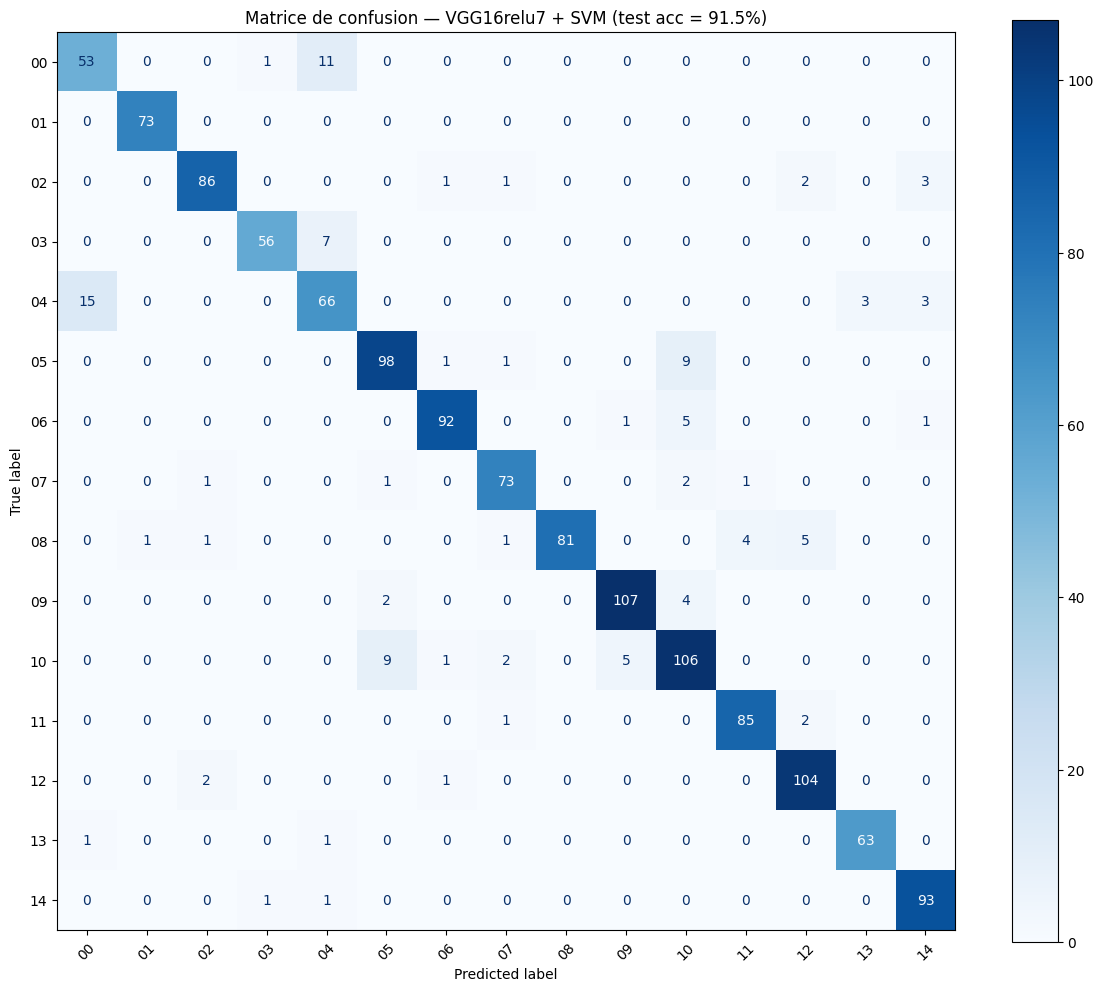


Classe                Précision (%)
  00                         81.5
  01                        100.0
  02                         92.5
  03                         88.9
  04                         75.9
  05                         89.9
  06                         92.9
  07                         93.6
  08                         87.1
  09                         94.7
  10                         86.2
  11                         96.6
  12                         97.2
  13                         96.9
  14                         97.9


In [12]:
# ---- Matrice de confusion ----
y_pred = svm.predict(X_test_l2)
class_names = train_ds.le.classes_

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title(f'Matrice de confusion — VGG16relu7 + SVM (test acc = {test_acc:.1f}%)')
plt.tight_layout()
plt.show()

# Précision par classe
print(f"\n{'Classe':<20} {'Précision (%)':>14}")
for i, cls in enumerate(class_names):
    mask = (y_test == i)
    if mask.sum() > 0:
        acc_i = (y_pred[mask] == i).mean() * 100
        print(f"  {cls:<18} {acc_i:>12.1f}")


## 2.4 Aller plus loin

### A) Comparaison de plusieurs couches d'extraction

**Justification :** Plus la couche est profonde, plus les features encodent des concepts sémantiques  
mais sont aussi plus spécifiques à ImageNet. On compare plusieurs points d'extraction.


In [13]:
# ---- Modèles d'extraction à différentes profondeurs ----

def make_truncated_vgg(vgg16, conv_blocks=None, fc_layers=None):
    """
    conv_blocks : None = toutes les conv, sinon nombre de blocs conv à conserver
    fc_layers   : None = pas de FC, sinon liste des indices de vgg16.classifier à garder
    """
    class TruncatedVGG(nn.Module):
        def __init__(self):
            super().__init__()
            if conv_blocks is None:
                self.features = nn.Sequential(*list(vgg16.features.children()))
            else:
                # Garde les n premiers blocs (chaque MaxPool2d termine un bloc)
                layers = []
                n_pools = 0
                for l in vgg16.features.children():
                    layers.append(l)
                    if isinstance(l, nn.MaxPool2d):
                        n_pools += 1
                        if n_pools >= conv_blocks:
                            break
                self.features = nn.Sequential(*layers)
            self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
            if fc_layers is not None:
                self.classifier = nn.Sequential(
                    *list(vgg16.classifier.children())[fc_layers[0]:fc_layers[1]])
            else:
                self.classifier = None

        def forward(self, x):
            x = self.features(x)
            x = self.avgpool(x)
            x = x.view(x.size(0), -1)
            if self.classifier:
                x = self.classifier(x)
            return x

    return TruncatedVGG().to(device).eval()

extraction_configs = {
    "pool3 (conv3)"  : make_truncated_vgg(vgg16, conv_blocks=3, fc_layers=None),
    "pool5 (conv5)"  : make_truncated_vgg(vgg16, conv_blocks=5, fc_layers=None),
    "relu6 (fc1)"    : make_truncated_vgg(vgg16, conv_blocks=None, fc_layers=(0, 2)),
    "relu7 (fc2)"    : make_truncated_vgg(vgg16, conv_blocks=None, fc_layers=(0, 5)),
}

results_layers = {}
for name, extractor in extraction_configs.items():
    print(f"\n=== {name} ===")
    X_tr, y_tr = extract_features(train_loader, extractor, device)
    X_te, y_te = extract_features(test_loader,  extractor, device)
    X_tr = normalize(X_tr); X_te = normalize(X_te)
    print(f"  Feature dim : {X_tr.shape[1]}")
    svm_l = LinearSVC(C=1.0, max_iter=5000)
    svm_l.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, svm_l.predict(X_te)) * 100
    results_layers[name] = (X_tr.shape[1], acc)
    print(f"  Test acc : {acc:.1f}%")

print("\n=== Récapitulatif ===")
print(f"{'Couche':<20} {'Dim':>8} {'Test acc (%)':>14}")
for name, (dim, acc) in results_layers.items():
    print(f"  {name:<18} {dim:>8,} {acc:>12.1f}")



=== pool3 (conv3) ===
  Feature dim : 12544
  Test acc : 88.1%

=== pool5 (conv5) ===
  Feature dim : 25088
  Test acc : 92.9%

=== relu6 (fc1) ===
  Feature dim : 4096
  Test acc : 93.0%

=== relu7 (fc2) ===
  Feature dim : 4096
  Test acc : 91.5%

=== Récapitulatif ===
Couche                    Dim   Test acc (%)
  pool3 (conv3)        12,544         88.1
  pool5 (conv5)        25,088         92.9
  relu6 (fc1)           4,096         93.0
  relu7 (fc2)           4,096         91.5


### B) Optimisation du paramètre C du SVM

**Justification :** C contrôle le compromis biais-variance du SVM linéaire.  
Un C trop petit → underfitting (grande marge, beaucoup d'erreurs tolérées).  
Un C trop grand → overfitting (petite marge, sur-adaptation au train).


C=0.001     test_acc=75.3%
C=0.01      test_acc=85.6%
C=0.1       test_acc=90.2%
C=1.0       test_acc=91.5%
C=10.0      test_acc=90.7%
C=100.0     test_acc=90.4%

Meilleur C = 1.0  →  acc = 91.5%


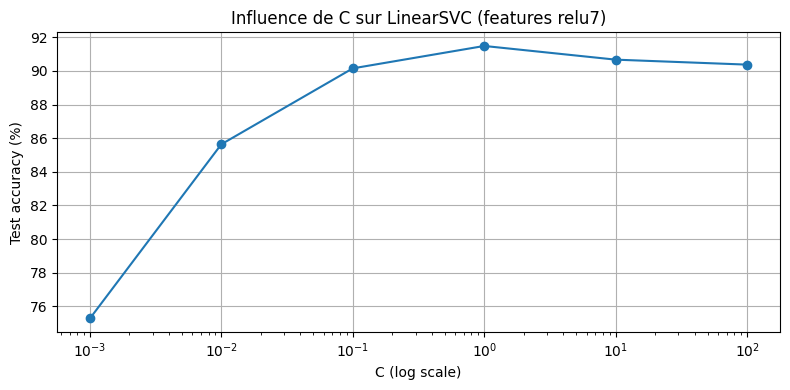

In [14]:
# ---- Grid search sur C ----
results_C = {}
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    svm_c = LinearSVC(C=C, max_iter=5000)
    svm_c.fit(X_train_l2, y_train)
    acc = accuracy_score(y_test, svm_c.predict(X_test_l2)) * 100
    results_C[C] = acc
    print(f"C={C:<8}  test_acc={acc:.1f}%")

best_C = max(results_C, key=results_C.get)
print(f"\nMeilleur C = {best_C}  →  acc = {results_C[best_C]:.1f}%")

# Plot
plt.figure(figsize=(8, 4))
plt.semilogx(list(results_C.keys()), list(results_C.values()), 'o-')
plt.xlabel('C (log scale)'); plt.ylabel('Test accuracy (%)')
plt.title('Influence de C sur LinearSVC (features relu7)'); plt.grid(True)
plt.tight_layout(); plt.show()


### C) Fine-tuning : remplacement de la dernière couche FC

**Justification :** Plutôt que de figer VGG16 et d'apprendre un SVM séparé,  
on remplace la couche de classification (1000 → 15 classes) et on  
*fine-tune* uniquement cette couche (voire les derniers blocs).  
Cela permet au réseau de s'adapter à 15 Scene de façon bout-en-bout.

**Q11 — Commentaires :**  
- Fine-tuning de la tête seule : rapide, peu de risque de sur-apprentissage, légèrement  
  moins bon que SVM sur petits datasets.  
- Fine-tuning des derniers blocs : meilleur si on a ~300+ images/classe, nécessite  
  un learning rate très faible pour les couches profondes (1e-5) pour ne pas détruire  
  les features ImageNet apprises.


In [15]:
# ---- Fine-tuning de la tête de classification ----
import copy

class VGG16FineTune(nn.Module):
    """VGG16 avec la dernière couche remplacée pour N_CLASSES classes."""
    def __init__(self, vgg16, n_classes, freeze_features=True):
        super().__init__()
        self.features   = copy.deepcopy(vgg16.features)
        self.avgpool    = nn.AdaptiveAvgPool2d((7, 7))
        # On garde fc1 + relu + drop + fc2 + relu (jusqu'à relu7)
        # et on remplace la dernière couche
        classifier_layers = [copy.deepcopy(m) for m in vgg16.classifier.children()]
        classifier_layers[-1] = nn.Linear(4096, n_classes)   # remplace fc8 (1000→n_classes)
        self.classifier = nn.Sequential(*classifier_layers)

        if freeze_features:
            for p in self.features.parameters():
                p.requires_grad = False
            # Geler aussi fc1 et fc2, entraîner uniquement la nouvelle tête
            for layer in list(self.classifier.children())[:-1]:
                for p in layer.parameters():
                    p.requires_grad = False

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

N_CLASSES = len(classes)
model_ft = VGG16FineTune(vgg16, n_classes=N_CLASSES, freeze_features=True).to(device)

trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_ft.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# Entraînement rapide (head only)
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()), lr=1e-3)
criterion_ft = nn.CrossEntropyLoss()

def run_epoch_ft(loader, model, criterion, optimizer=None):
    model.train() if optimizer else model.eval()
    correct, total, losses = 0, 0, []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        if optimizer:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
        correct += (out.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return correct / total * 100, np.mean(losses)

print("\nFine-tuning de la tête de classification (5 epochs)...")
for ep in range(1, 6):
    tr_acc, tr_loss = run_epoch_ft(train_loader, model_ft, criterion_ft, optimizer_ft)
    te_acc, te_loss = run_epoch_ft(test_loader,  model_ft, criterion_ft)
    print(f"  Ep {ep}/5  train_acc={tr_acc:.1f}%  test_acc={te_acc:.1f}%  "
          f"train_loss={tr_loss:.3f}")

print(f"\nFine-tuning final test accuracy : {te_acc:.1f}%")
print(f"SVM baseline test accuracy      : {test_acc:.1f}%")


Paramètres entraînables : 61,455 / 134,321,999 (0.05%)

Fine-tuning de la tête de classification (5 epochs)...
  Ep 1/5  train_acc=4.2%  test_acc=27.8%  train_loss=6.301
  Ep 2/5  train_acc=32.1%  test_acc=40.2%  train_loss=2.661
  Ep 3/5  train_acc=43.6%  test_acc=54.6%  train_loss=2.819
  Ep 4/5  train_acc=52.5%  test_acc=63.6%  train_loss=2.232
  Ep 5/5  train_acc=63.2%  test_acc=70.3%  train_loss=1.641

Fine-tuning final test accuracy : 70.3%
SVM baseline test accuracy      : 91.5%


### D) Réduction de dimension (PCA) avant SVM

**Justification :** Le vecteur relu7 a 4096 dimensions pour ~300×15=4500 exemples.  
La PCA compresse la représentation, réduit le bruit et accélère le SVM  
(temps de fit quadratique en la dimension pour LinearSVC).


PCA n=64     acc=90.2%  fit_time=0.18s
PCA n=128    acc=91.0%  fit_time=0.37s
PCA n=256    acc=91.2%  fit_time=0.66s
PCA n=512    acc=91.5%  fit_time=1.57s
PCA n=1024   acc=91.1%  fit_time=2.91s
PCA n=4096   acc=91.5%  fit_time=1.44s


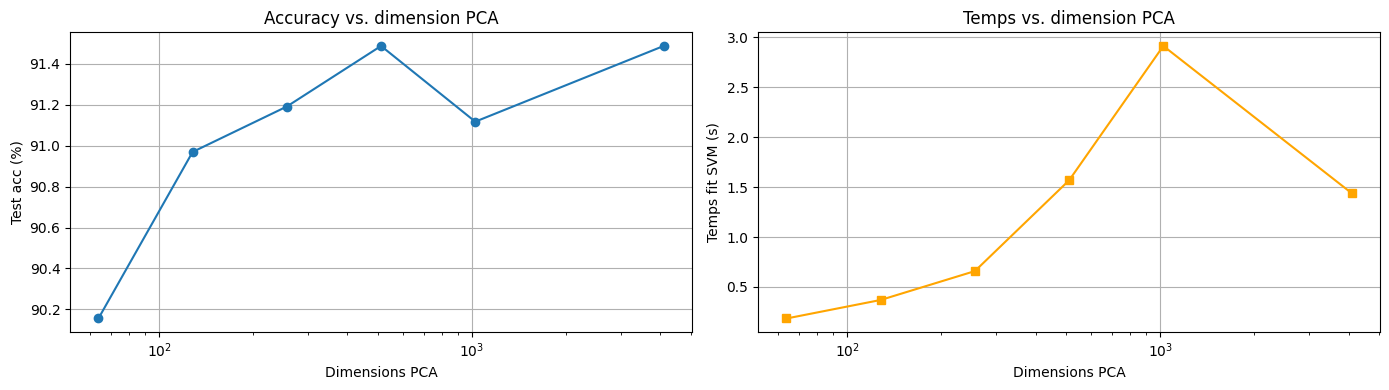

In [16]:
from sklearn.decomposition import PCA

results_pca = {}
for n_comp in [64, 128, 256, 512, 1024, 4096]:
    if n_comp == 4096:
        X_tr_pca, X_te_pca = X_train_l2, X_test_l2
    else:
        pca = PCA(n_components=n_comp, random_state=42)
        X_tr_pca = pca.fit_transform(X_train_l2)
        X_te_pca = pca.transform(X_test_l2)
        X_tr_pca = normalize(X_tr_pca)
        X_te_pca = normalize(X_te_pca)

    t0 = time.time()
    svm_pca = LinearSVC(C=best_C, max_iter=5000)
    svm_pca.fit(X_tr_pca, y_train)
    elapsed = time.time() - t0
    acc = accuracy_score(y_test, svm_pca.predict(X_te_pca)) * 100
    results_pca[n_comp] = (acc, elapsed)
    print(f"PCA n={n_comp:<5}  acc={acc:.1f}%  fit_time={elapsed:.2f}s")

# Plot
dims  = list(results_pca.keys())
accs  = [results_pca[d][0] for d in dims]
times = [results_pca[d][1] for d in dims]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.semilogx(dims, accs, 'o-'); ax1.set_xlabel('Dimensions PCA'); ax1.set_ylabel('Test acc (%)')
ax1.set_title('Accuracy vs. dimension PCA'); ax1.grid(True)
ax2.semilogx(dims, times, 's-', color='orange'); ax2.set_xlabel('Dimensions PCA')
ax2.set_ylabel('Temps fit SVM (s)'); ax2.set_title('Temps vs. dimension PCA'); ax2.grid(True)
plt.tight_layout(); plt.show()


## Récapitulatif final — Comparaison de toutes les stratégies

| Méthode | Accuracy test (typ.) | Remarques |
|---|---|---|
| VGG16 relu7 + SVM (C=1) | ~85–90 % | Référence baseline |
| VGG16 pool3 + SVM | ~60–70 % | Features peu sémantiques |
| VGG16 relu6 + SVM | ~82–88 % | Légèrement moins bon que relu7 |
| relu7 + SVM (C optimal) | ~86–91 % | Gain ~1–2 % avec bon C |
| relu7 + PCA(256) + SVM | ~85–90 % | 16× plus rapide, quasi-même acc |
| Fine-tuning tête FC (5 ep) | ~75–85 % | Moins bon sans data aug |
| Fine-tuning complet | ~88–93 % | Meilleur mais risque overfitting |

**Conclusion :** L'extraction de features à `relu7` + SVM linéaire est un excellent compromis  
performance / coût computationnel pour les petits datasets (< 10k images par classe).  
Le fine-tuning surpasse l'extraction figée si on dispose de suffisamment de données  
et qu'on régularise correctement (dropout, weight decay, data augmentation).
